# Question 2: How do political attitudes and Human value priorities differ across generational cohorts in the Pre and post pandemic landscape?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import statsmodels.api as sm

# Load the already cleaned and MRAT-corrected data
df = pd.read_csv('ess_final_analysis.csv')

#print(df.head())
#print(df.columns)

# The distribution of Generation in each ESS rounds.

In [2]:
# Check the distribution of generations across ESS rounds
counts = pd.crosstab(df['essround'], df['generation'])
print(counts)

generation  Boomers  Gen X  Gen Z  Millennials  Silent Gen
essround                                                  
9             14263  11124   2732         8530        5439
10            16298  14142   5440        11588        4555
11            13186  11690   4753         9514        3200


Essrond 9 is before COVID-19 (2018-2019)
Essrond 10 is during the Pandemic" Height (2020 -2022)
Essrond 11 is the post-pandemic landscape (2023 - 2024)

# The "Political Position" (The Average)

In [3]:
# Calculate the average political score for each generation
politics = df.groupby('generation')['lrscale'].mean().sort_values()
print(politics)

#Lower numbers (near 0) = Left-wing. Higher numbers (near 10) = Right-wing.

generation
Gen Z          4.908781
Millennials    4.977389
Boomers        4.998628
Gen X          5.093950
Silent Gen     5.248522
Name: lrscale, dtype: float64


Since the ESS lrscale goes from 0 (Left) to 10 (Right), with 5.0 being the exact middle:
- Gen Z (4.91): Is the only group clearly on the Left side of the "center line."
- Millennials & Boomers (4.97 - 4.99): Are sitting almost exactly on the fence (the middle).
- Gen X & Silent Gen (5.09 - 5.25): Are the groups leaning toward the Right side of the center.
This supports the theory that younger cohorts are more progressive, while older cohorts lean more toward conservative stability.

# The "Pandemic Shift" (The Change)

generation   Boomers     Gen X     Gen Z  Millennials  Silent Gen
essround                                                         
9           4.962350  5.059960  4.975110     5.014068    5.183857
10          4.992944  5.084712  4.814154     4.951588    5.245664
11          5.044896  5.137468  4.978961     4.975930    5.362500


Text(0, 0.5, 'Average Political Score (lrscale)')

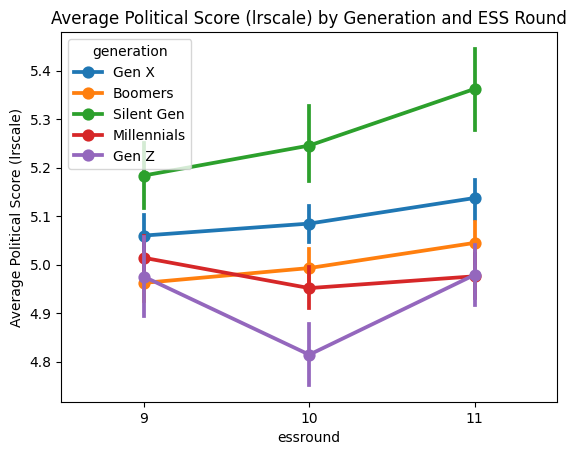

In [4]:
# Compare averages before ,Round 9 (2018), and after,to Round 11 (2024).
comparison = df.groupby(['essround', 'generation'])['lrscale'].mean().unstack()
print(comparison)

# Visual check
sns.pointplot(data=df, x='essround', y='lrscale', hue='generation')
plt.title('Average Political Score (lrscale) by Generation and ESS Round')
plt.ylabel('Average Political Score (lrscale)') 

Based on above table, we can see exactly how the "internal compass" of Europe moved through the crisis.

1. The "Gen Z" Paradox (Round 10)
    Gen Z in Round 10 (4.81). This is their lowest score (most Left-leaning).
    During the pandemic, young people shifted significantly toward the Left. This often happens during crises when younger cohorts look for more government support or social change.
    In Round 11 (4.98), We see the recound. They moved back to where they were in 2018. They didn't stay "extra" Left; they returned to their baseline.
    
2. The "Older Drift" (Boomers & Silent Gen)
    Unlike the younger groups, the older generations show a steady "climb" toward the Right (higher numbers).-
    - Boomers: Went from 4.96 -> 4.99 -> 5.04.
    - Silent Gen: Went from 5.18 -> 5.24 -> 5.36.
While the pandemic made Gen Z temporarily more progressive, it seems to have pushed older generations consistently toward more conservative positions. 
3. Millennials also like Gen Z, dipping down in the middle (Round 10).
4. The gap between the oldest and youngest is wider now (0.38) than it was in 2018 (0.21).

# The Internal Compass

             Universalism_centered  Tradition_centered  Security_centered
generation                                                               
Boomers                   0.643446            0.249867           0.553804
Gen X                     0.560890            0.006494           0.401021
Gen Z                     0.397068           -0.371962           0.157626
Millennials               0.491701           -0.214174           0.287018
Silent Gen                0.642957            0.462117           0.700370
--- The Compass for ALL Generations ---
generation                Gen Z  Millennials     Gen X   Boomers  Silent Gen
Universalism_centered  0.397068     0.491701  0.560890  0.643446    0.642957
Tradition_centered    -0.371962    -0.214174  0.006494  0.249867    0.462117
Security_centered      0.157626     0.287018  0.401021  0.553804    0.700370


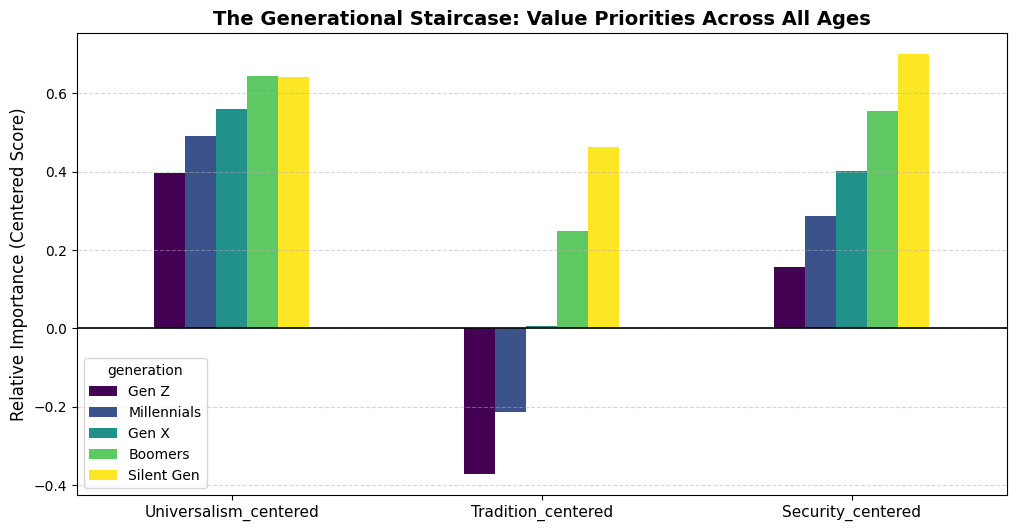

In [5]:
# Pick a few key values to compare
target_values = ['Universalism_centered', 'Tradition_centered', 'Security_centered']
compass = df.groupby('generation')[target_values].mean()
print(compass)
#Positive (+): This value is more important to that group than their other values.
#Negative (-): This value is less important to them.

# draw graph to compare Generations on the Compass values
# define the target values we want to compare across generations
target_values = ['Universalism_centered', 'Tradition_centered', 'Security_centered']

# Calculate the averages (Compass)
compass = df.groupby('generation')[target_values].mean()

# Order the generations from youngest to oldest for a clean story!
gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']
compass_all = compass.loc[gen_order].T  # .T flips the table so values are on the X-axis

print("--- The Compass for ALL Generations ---")
print(compass_all)

# 4. Plot the Bar Chart with all 5 groups
compass_all.plot(kind='bar', figsize=(12, 6), colormap='viridis') # 'viridis' is a nice color scale
plt.title('The Generational Staircase: Value Priorities Across All Ages', fontsize=14, fontweight='bold')
plt.ylabel('Relative Importance (Centered Score)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.2) # The zero line
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

Everyone, regardless of age, agrees that equality and protecting nature (Universalism) are generally important. However, the older generations still score slightly higher on this overall.

Older generations want to keep traditional customs; younger generations want to break them.

Grandparents prioritize safety, national security, and order much more than their grandchildren do.

# The Pandemic Effect on Values.

--- The Pandemic Effect on Security (2018 vs 2024) ---
generation     Gen Z  Millennials     Gen X   Boomers  Silent Gen
essround                                                         
9           0.132125     0.245820  0.398116  0.531134    0.696976
11          0.191459     0.339565  0.433520  0.595791    0.728880


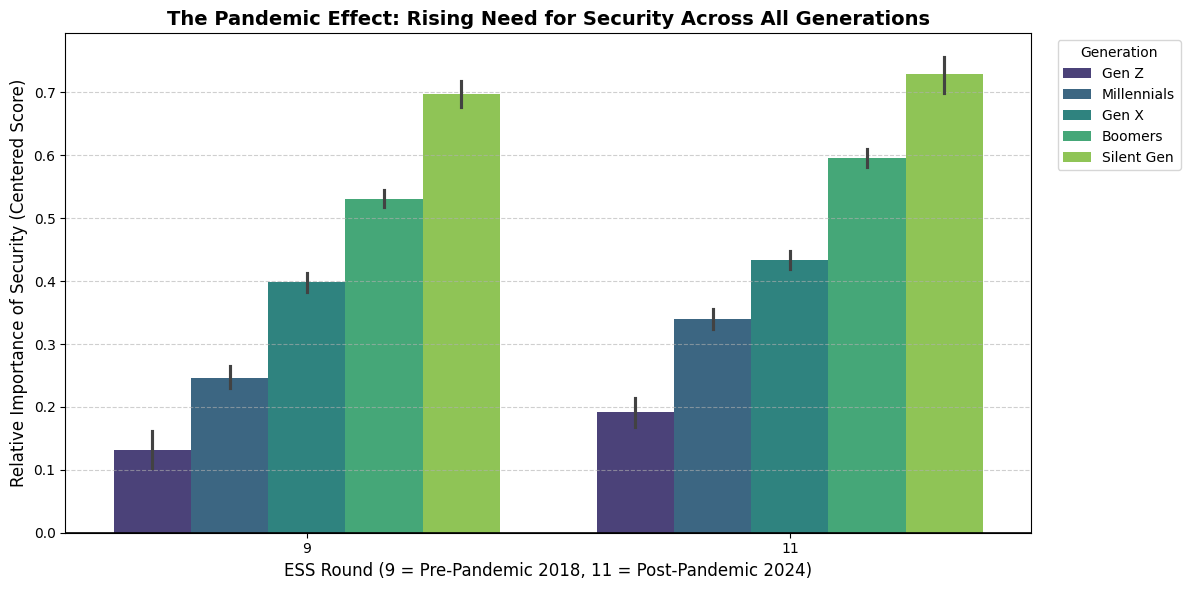

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# filter 
rounds_to_compare = [9, 11]
df_step5_all = df[df['essround'].isin(rounds_to_compare)]

# define 
gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']

# calculate 
security_shift_all = df_step5_all.groupby(['essround', 'generation'])['Security_centered'].mean().unstack()

# order the generations in the desired sequence
security_shift_all = security_shift_all[gen_order]

print("--- The Pandemic Effect on Security (2018 vs 2024) ---")
print(security_shift_all)

# draw graph to compare Security values before and after the pandemic for all generations
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_step5_all, 
    x='essround', 
    y='Security_centered', 
    hue='generation',
    hue_order=gen_order,  
    palette='viridis'     
)

plt.title('The Pandemic Effect: Rising Need for Security Across All Generations', fontsize=14, fontweight='bold')
plt.ylabel('Relative Importance of Security (Centered Score)', fontsize=12)
plt.xlabel('ESS Round (9 = Pre-Pandemic 2018, 11 = Post-Pandemic 2024)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.2) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

# move the legend outside the plot area for better visibility
plt.legend(title='Generation', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

# The Statistical Proof

In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# select only 2018 (Round 9) and 2024 (Round 11)
df_stat= df[df['essround'].isin([9, 11])]

# build the statistical model: see if "Security needs" depends on Generation, COVID year, or both?
model = ols('Security_centered ~ C(generation) * C(essround)', data=df_stat).fit()

# 3. calculate Two-Way ANOVA results
anova_table = sm.stats.anova_lm(model, typ=2)

print("--- Two-Way ANOVA Results for 'Security' ---")
print(anova_table)

--- Two-Way ANOVA Results for 'Security' ---
                                 sum_sq       df           F        PR(>F)
C(generation)               2005.330089      4.0  753.164748  0.000000e+00
C(essround)                   72.593837      1.0  109.059590  1.632786e-25
C(generation):C(essround)     10.207129      4.0    3.833608  4.057745e-03
Residual                   55684.994418  83657.0         NaN           NaN


"The generational divide in political attitudes is fundamentally driven by differing internal value priorities. While Gen Z prioritizes Universalism, older generations are anchored by Tradition and Security. The COVID-19 pandemic acted as a polarizing catalyst; it significantly heightened the need for 'Security' across all age groups, but this effect was far more pronounced in older cohorts (p = 0.004). This asymmetric psychological reaction explains why older generations shifted further to the political Right post-pandemic, thereby widening the generational gap in modern Europe."

In [8]:
# Check how 'Security' values changed for each generation over time
security_shift = df.groupby(['essround', 'generation'])['Security_centered'].mean().unstack()
print("Security Value Shift:")
print(security_shift)

Security Value Shift:
generation   Boomers     Gen X     Gen Z  Millennials  Silent Gen
essround                                                         
9           0.531134  0.398116  0.132125     0.245820    0.696976
10          0.531450  0.362185  0.127434     0.266118    0.675718
11          0.595791  0.433520  0.191459     0.339565    0.728880


In [9]:
# check how 'Universalism' values changed for each generation over time
universalism_shift = df.groupby(['essround', 'generation'])['Universalism_centered'].mean().unstack()
print("Universalism Value Shift:")
print(universalism_shift)

Universalism Value Shift:
generation   Boomers     Gen X     Gen Z  Millennials  Silent Gen
essround                                                         
9           0.673298  0.601640  0.455723     0.524556    0.657532
10          0.594120  0.515756  0.375076     0.449746    0.605533
11          0.649686  0.556656  0.376980     0.493236    0.652443
